***Step1:- Import Libraries***

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Load The Data
df = pd.read_csv('/content/student_scores.csv')

In [5]:
#Check the First 5 Row's
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


**Based On The Numbers Of Hours Of Study Build A ML Model To Pridict The Score**


*   Is There Any Categorical Columns -- No
*  We Have Two Columns -- Hour{Float} Score -- {int}



In [6]:
df.shape

(25, 2)

***DATA JAR***

In [7]:
#Here We Clean The Data , Encode The Data, Split The Data, Scale The Data
#Scaling Is Not Mandatory For The Linear Regression


**Data Cleaning**

In [8]:
#Check the Data Type
df.dtypes

,0
Hours,float64
Scores,int64


In [9]:
#Check the Null Values
df.isnull().sum()

,0
Hours,0
Scores,0


In [10]:
# Check the Outlier In The DAta
# Outlier- Extreme Range Of Data
df.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [11]:
#Find The IQR Value's --75%
iqr = df["Hours"].quantile(0.75) - df["Hours"].quantile(0.25)
iqr

np.float64(4.7)

In [12]:
# Calculate Q3 (75th percentile)
Q3 = df['Hours'].quantile(0.75)
print(Q3)

# Given IQR
IQR = 4.7

# Calculate Upper Limit
UL = Q3 + (1.5 * IQR)
print(UL)

7.4
14.450000000000001


In [13]:
q3 = print(df["Hours"].quantile(0.75))

7.4


In [14]:
# Calculate Q1 (25th percentile)
Q1 = df['Hours'].quantile(0.25)
print(Q1)

# Given IQR
IQR = 4.7

# Calculate Lower Limit
LL = Q1 - (1.5 * IQR)
print(LL)

2.7
-4.3500000000000005


In [15]:
df.describe()


,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [16]:
# In the 'Hours' column
# Minimum value
min_hours = 1.1

# Maximum value
max_hours = 9.2

# Upper Limit (UL)
UL = 14.45

# Lower Limit (LL)
LL = -4.3

print("Min Hours:", min_hours)
print("Max Hours:", max_hours)
print("Upper Limit:", UL)
print("Lower Limit:", LL)

Min Hours: 1.1
Max Hours: 9.2
Upper Limit: 14.45
Lower Limit: -4.3


***Checking The Outlier's***

In [17]:
# Data values
values = [-4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

# Lower and Upper Limits
LL = -4.3
UL = 14.45

# Check for outliers
outliers = [x for x in values if x < LL or x > UL]

# Condition
if len(outliers) == 0:
    print("No outliers present")
else:
    print("Outliers:", outliers)

No outliers present


In [18]:
#Check the duplicates
df.duplicated().sum()

np.int64(0)



*   **There Is No Null Values**
*   **The Data Type Format Is Correct**
*  **No Dupliactes To Drop**
*  **No Outlier's**


***Encode the Data***

In [19]:
#There Is No Categorical Data So We Dont Need To Encode The Data

***Split The Data***

In [20]:
#Before Spliting We Need To First Define The Features And Target Variable

Text(0.5, 1.0, 'Hours vs Percentage')

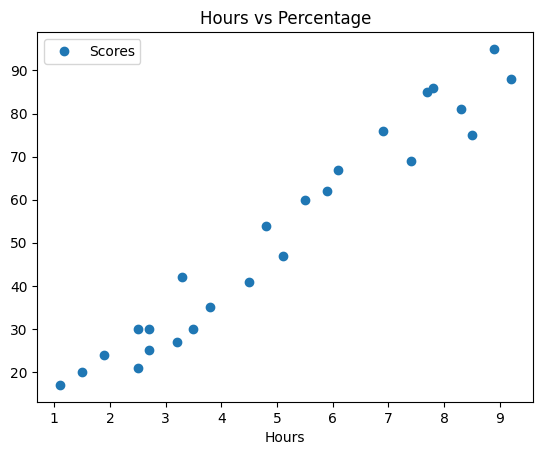

In [21]:
#Check The Linear Relationship Between Data
df.plot(x="Hours", y="Scores", style="o")
plt.title("Hours vs Percentage")

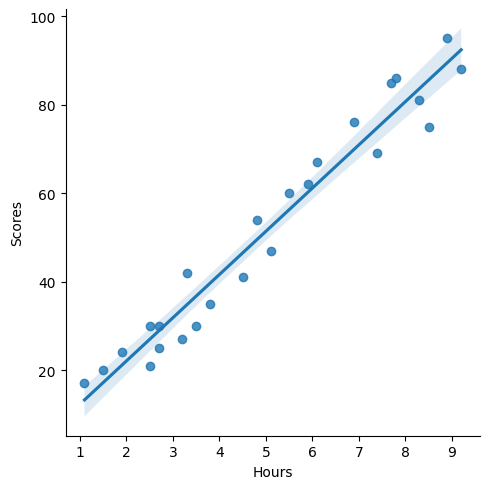

In [22]:
import seaborn as sns

# lmplot -> used for statistical relationship (linear regression visualization)
sns.lmplot(data=df, x="Hours", y="Scores")




*  **There Is A Straight Line Between Hours & Score**
*  **No Transformation Is Required**



In [23]:
#Another Way To check the strenght of linear
df.corr()

,Hours,Scores
Hours,1.000000,0.976191
Scores,0.976191,1.000000


In [24]:
df["Hours"]

,Hours
0,2.5
1,5.1
2,3.2
3,8.5
4,3.5
5,1.5
6,9.2
7,5.5
8,8.3
9,2.7


In [25]:
X = df.loc[:, ['Hours']].values #feature
y = df.loc[:,'Scores'].values #feature

In [26]:
X

array([[2.5],
       [5.1],
       [3.2],
       [8.5],
       [3.5],
       [1.5],
       [9.2],
       [5.5],
       [8.3],
       [2.7],
       [7.7],
       [5.9],
       [4.5],
       [3.3],
       [1.1],
       [8.9],
       [2.5],
       [1.9],
       [6.1],
       [7.4],
       [2.7],
       [4.8],
       [3.8],
       [6.9],
       [7.8]])

In [27]:
y

array([21, 47, 27, 75, 30, 20, 88, 60, 81, 25, 85, 62, 41, 42, 17, 95, 30,
       24, 67, 69, 30, 54, 35, 76, 86])

***Split The Data***

*   Training   --- 70-80% Data
*  Testing     --- 20-30% Data




In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
X_train
#Random State Is Used To Get The Fixed Sample Or Stable Sample.

array([[7.8],
       [6.9],
       [1.1],
       [5.1],
       [7.7],
       [3.3],
       [8.3],
       [9.2],
       [6.1],
       [3.5],
       [2.7],
       [5.5],
       [2.7],
       [8.5],
       [2.5],
       [4.8],
       [8.9],
       [4.5]])

***Scaling The Data***

In [29]:
#It's Not Mandatory For Linear Regression.


# ***Task_Jar***

In [30]:
#SuperVised_Learning
#Here We Deal With Labeled Data So We Know The Target Variable's

# ***Model Jar***

In [ ]:
#Mathametical Representattion Of Linear Regression.
#Y = Mx+c


In [32]:
from sklearn.linear_model import LinearRegression
# Initialize The Linear Regression
regressor = LinearRegression()
#Fit The Model
regressor.fit(X_train, y_train)

LinearRegression()

In [33]:
# 'C' Is Known As Interception.
print(regressor.intercept_)

1.9322042531516601


In [35]:
# 'M' Slope(coef_)
print(regressor.coef_)

[9.94167834]


In [37]:
# Predict Score Y = 9.9 + X + 1.93
regressor.predict([[4.5]])

array([46.66975678])

In [38]:
y_pred = regressor.predict(X_test)
y_pred

array([16.84472176, 33.74557494, 75.50062397, 26.7864001 , 60.58810646,
       39.71058194, 20.8213931 ])

In [40]:
data = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
data


,Actual,Predicted
0,20,16.844722
1,27,33.745575
2,69,75.500624
3,30,26.786400
4,62,60.588106
5,35,39.710582
6,24,20.821393


***Check With Another Random State***

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=45)
X_train
#Random State Is Used To Get The Fixed Sample Or Stable Sample.

array([[7.4],
       [3.2],
       [6.1],
       [4.5],
       [5.5],
       [8.3],
       [9.2],
       [2.7],
       [1.5],
       [1.1],
       [5.1],
       [8.9],
       [3.5],
       [6.9],
       [4.8],
       [2.5],
       [8.5],
       [5.9]])

# ***Testing***

In [42]:
from sklearn.linear_model import LinearRegression
# Initialize The Linear Regression
regressor = LinearRegression()
#Fit The Model
regressor.fit(X_train, y_train)

LinearRegression()

In [43]:
y_pred = regressor.predict(X_test)
y_pred

array([25.73153298, 27.67553458, 33.5075394 , 76.27557474, 19.89952816,
       77.24757554, 38.36754342])

In [44]:
data = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
data


,Actual,Predicted
0,30,25.731533
1,30,27.675535
2,42,33.507539
3,85,76.275575
4,24,19.899528
5,86,77.247576
6,35,38.367543


# ***Evaluation Jar***

In [47]:
#R2- Score
from sklearn import metrics
print("R2-Score", metrics.r2_score(y_test, y_pred))

R2-Score 0.9347551352640703


* *My Linear regression model it predicts* ***92%*** *of values are correct*
* **in general if the model eavlaution score is more then 75% then it is a good model**